### Permutation in String


- You are given two strings s1 and s2.

- Return true if s2 contains a permutation of s1, or false otherwise. That means if a permutation of s1 exists as a substring of s2, then return true.

- Both strings only contain lowercase letters.

### Example 1:

Input: s1 = "abc", s2 = "lecabee"

Output: true
Explanation: The substring "cab" is a permutation of "abc" and is present in "lecabee".

### Example 2:

Input: s1 = "abc", s2 = "lecaabee"

Output: false


### Constraints:

- 1 <= s1.length, s2.length <= 1000



# lets go !!!
- there are 2 solutions
    - O(26*n) and O(n)
    - we focus on O(n) because its a pattern that is used in other problems aswell
    - given s1 and s2,true if s2 contains a permutation of s1 else false
    - 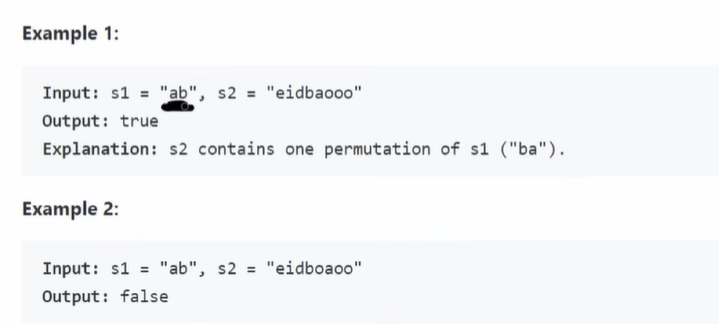
    - eg: s1 is the target string , we are checking if a permutation of s1 is inside of s2, can we find it?
    - we can try doing the permutation of the string which will be complex and annoying
    - what we are actually looking for is if we have a substring of exactly len(s1) and say if that's a permutations
        - we are looking for a window same size as s1, and that contains exact same chars of s1, but maybe in a diff order
        - its same as anagram
        - so we can use a sliding window technique
        - if we are matching the exact char , then it will be annoying , T.C will be O(n.m) (n=len(s2),m=len(s1)) because we are looking at every single window.
        - we can reduce it to be 26*n if we use a Hashmap
        - `NOTE: in the bottom we have a constraint that all the characters are limited to a-z in lowercase`
        - i.e the size of Hashmap is atmost 26, so as we build it
        - we gonna build 2 hashmap, 1 for s1, which will be exactly same and we are also going to have










In [ ]:
class Solution:
    def checkInclusion(self, s1: str, s2: str) -> bool:
        if len(s1) > len(s2):
            return False

        target = [0] * 26
        window = [0] * 26

        for c in s1:
            target[ord(c) - ord('a')] += 1

        for i in range(len(s1)):
            window[ord(s2[i]) - ord('a')] += 1

        if target == window:
            return True

        for i in range(len(s1), len(s2)):
            window[ord(s2[i]) - ord('a')] += 1
            window[ord(s2[i - len(s1)]) - ord('a')] -= 1

            if target == window:
                return True

        return False

build target frequency
build first window frequency

while sliding:
    add right char
    remove left char
    compare frequencies

In [ ]:
class Solution:
    def checkInclusion(self, s1: str, s2: str) -> bool:
        if len(s1) > len(s2):
            return False

        s1_count = [0] * 26
        window = [0] * 26

        # Build frequency arrays
        for i in range(len(s1)):
            s1_count[ord(s1[i]) - ord('a')] += 1
            window[ord(s2[i]) - ord('a')] += 1

        # Count how many positions currently match
        matches = 0
        for i in range(26):
            if s1_count[i] == window[i]:
                matches += 1

        left = 0

        for right in range(len(s1), len(s2)):
            if matches == 26:
                return True

            # Add new character to window
            idx = ord(s2[right]) - ord('a')
            window[idx] += 1

            if window[idx] == s1_count[idx]:
                matches += 1
            elif window[idx] == s1_count[idx] + 1:
                matches -= 1

            # Remove left character from window
            idx = ord(s2[left]) - ord('a')
            window[idx] -= 1

            if window[idx] == s1_count[idx]:
                matches += 1
            elif window[idx] == s1_count[idx] - 1:
                matches -= 1

            left += 1

        return matches == 26